In [1]:
# Environment setup
import sys
from pathlib import Path

# Find the project root by walking up from cwd until we find `config/`
def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "config").is_dir() and (p / "src").is_dir():
            return p
    raise RuntimeError(f"Could not find project root from {start}")

PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"Working directory: {Path.cwd()}")

Project root: /Users/mac/Studying/OTTO/scenario_generator
Working directory: /Users/mac/Studying/OTTO/scenario_generator/notebooks


In [2]:
# Load scenario and inspect resolved faults
from src.config_loader import ConfigLoader
from src.signal_generator import Scenario

loader = ConfigLoader(PROJECT_ROOT / "config")
fault_registry = loader.load_fault_types()

scenario_path = PROJECT_ROOT / "config" / "scenarios" / "highway_brake_wear_gradual.yaml"
scenario = Scenario.from_yaml(scenario_path, fault_registry=fault_registry)

print(f"Scenario:      {scenario.name}")
print(f"Duration:      {scenario.duration_s} s")
print(f"Vehicle:       {scenario.vehicle_id}")
print(f"Segments:      {len(scenario.segments)}")
print(f"Resolved faults: {len(scenario.resolved_faults)}")
print()
for f in scenario.resolved_faults:
    print(f"  [{f.id}] {f.type}")
    print(f"      window:     [{f.onset_s:.2f}, {f.end_s:.2f}] s")
    print(f"      severity:   {f.params['severity_start']} → {f.params['severity_end']} ({f.params['progression']})")
    print(f"      targets:    {f.targets['signals']}")
    print()

Scenario:      Highway Cruise with Brake Wear
Duration:      90.0 s
Vehicle:       suv_b
Segments:      8
Resolved faults: 2

  [wear_1] brake_pad_wear
      window:     [38.00, 82.00] s
      severity:   0.0 → 0.4 (linear)
      targets:    ['longitudinal_acceleration']

  [tamper_1] brake_pad_wear
      window:     [85.00, 90.00] s
      severity:   0.0 → 0.6 (step)
      targets:    ['longitudinal_acceleration']



In [3]:
# Generate clean and corrupted signals
from src.fault_injector import SignalFaultInjector
from src.signal_generator import SignalGenerator

generator = SignalGenerator(loader)
injector = SignalFaultInjector(loader, generator)

# Clean (no faults applied)
clean_df = generator.generate(scenario)

# Corrupted (faults applied via injector)
corrupted_df, applied_faults = injector.apply(scenario)

print(f"Clean signals shape:      {clean_df.shape}")
print(f"Corrupted signals shape:  {corrupted_df.shape}")
print(f"Applied faults:           {len(applied_faults)}")
for a in applied_faults:
    print(f"  [{a.fault_id}] {a.fault_type}  [{a.onset_s:.2f}, {a.end_s:.2f}] s")

Clean signals shape:      (9000, 10)
Corrupted signals shape:  (9000, 10)
Applied faults:           2
  [wear_1] brake_pad_wear  [38.00, 82.00] s
  [tamper_1] brake_pad_wear  [85.00, 90.00] s


In [4]:
# Which signals actually changed?
import numpy as np
import pandas as pd

signals = [c for c in clean_df.columns if c != "time_s"]

diff_summary = []
for sig in signals:
    delta = (corrupted_df[sig] - clean_df[sig]).values
    abs_max = float(np.abs(delta).max())
    mean_abs = float(np.abs(delta).mean())
    nonzero = int((np.abs(delta) > 1e-9).sum())
    diff_summary.append({
        "signal": sig,
        "changed": nonzero > 0,
        "n_changed": nonzero,
        "max_abs_delta": abs_max,
        "mean_abs_delta": mean_abs,
    })

diff_df = pd.DataFrame(diff_summary)
print("Per-signal comparison (clean vs. corrupted):")
print(diff_df.to_string(index=False))

# Assert the expected cascade
changed_signals = set(diff_df.loc[diff_df["changed"], "signal"])
expected_changed = {
    "longitudinal_acceleration",
    "vehicle_speed",
    "wheel_speed",
    "engine_rpm",
}
unchanged_expected = set(signals) - expected_changed

assert changed_signals == expected_changed, (
    f"Cascade mismatch.\n"
    f"  Expected changed:   {sorted(expected_changed)}\n"
    f"  Actually changed:   {sorted(changed_signals)}\n"
    f"  Expected unchanged: {sorted(unchanged_expected)}\n"
    f"  Actually unchanged: {sorted(set(signals) - changed_signals)}"
)

print()
print("✅ Cascade is exactly as designed:")
print(f"   Changed:   {sorted(changed_signals)}")
print(f"   Unchanged: {sorted(set(signals) - changed_signals)}")

Per-signal comparison (clean vs. corrupted):
                   signal  changed  n_changed  max_abs_delta  mean_abs_delta
        throttle_position    False          0       0.000000        0.000000
              brake_pedal    False          0       0.000000        0.000000
                     gear    False          0       0.000000        0.000000
longitudinal_acceleration     True       2500       1.083236        0.107662
            vehicle_speed     True       2500      19.058803        2.665308
               engine_rpm     True       2500    2175.711007      159.832294
      coolant_temperature    False          0       0.000000        0.000000
           brake_pressure    False          0       0.000000        0.000000
              wheel_speed     True       2500      19.058803        2.665308

✅ Cascade is exactly as designed:
   Changed:   ['engine_rpm', 'longitudinal_acceleration', 'vehicle_speed', 'wheel_speed']
   Unchanged: ['brake_pedal', 'brake_pressure', 'coolant_tem

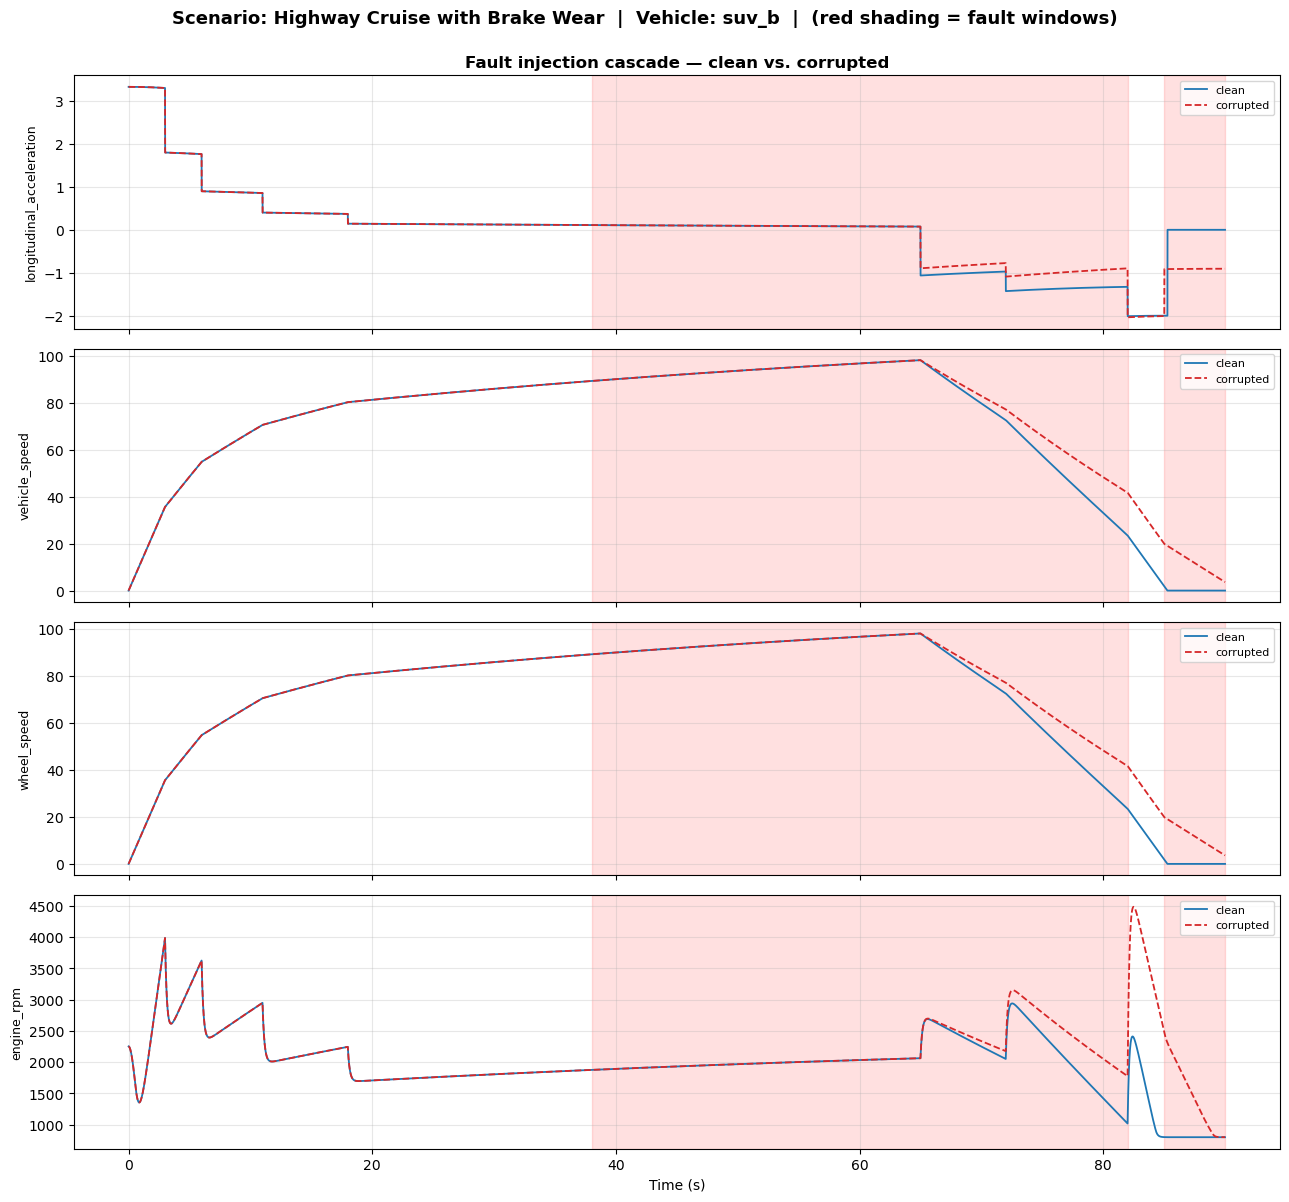

In [5]:
# Plot clean vs corrupted for the four cascade signals
import matplotlib.pyplot as plt

# Signals affected by the fault (the cascade)
cascade_signals = [
    "longitudinal_acceleration",
    "vehicle_speed",
    "wheel_speed",
    "engine_rpm",
]

fig, axes = plt.subplots(len(cascade_signals), 1, figsize=(13, 3 * len(cascade_signals)), sharex=True)

# Fault windows for shading
def shade_faults(ax):
    for f in scenario.resolved_faults:
        ax.axvspan(f.onset_s, f.end_s, alpha=0.12, color="red")

for ax, sig in zip(axes, cascade_signals):
    # Clean
    ax.plot(clean_df["time_s"], clean_df[sig], label="clean", color="tab:blue", linewidth=1.3)
    # Corrupted
    ax.plot(corrupted_df["time_s"], corrupted_df[sig], label="corrupted", color="tab:red", linewidth=1.3, linestyle="--")
    ax.set_ylabel(sig, fontsize=9)
    ax.grid(alpha=0.3)
    shade_faults(ax)
    ax.legend(fontsize=8, loc="upper right")

axes[0].set_title("Fault injection cascade — clean vs. corrupted", fontsize=12, fontweight="bold")
axes[-1].set_xlabel("Time (s)")

fig.suptitle(f"Scenario: {scenario.name}  |  Vehicle: {scenario.vehicle_id}  |  (red shading = fault windows)",
             fontsize=13, fontweight="bold", y=0.998)
plt.tight_layout()
plt.show()

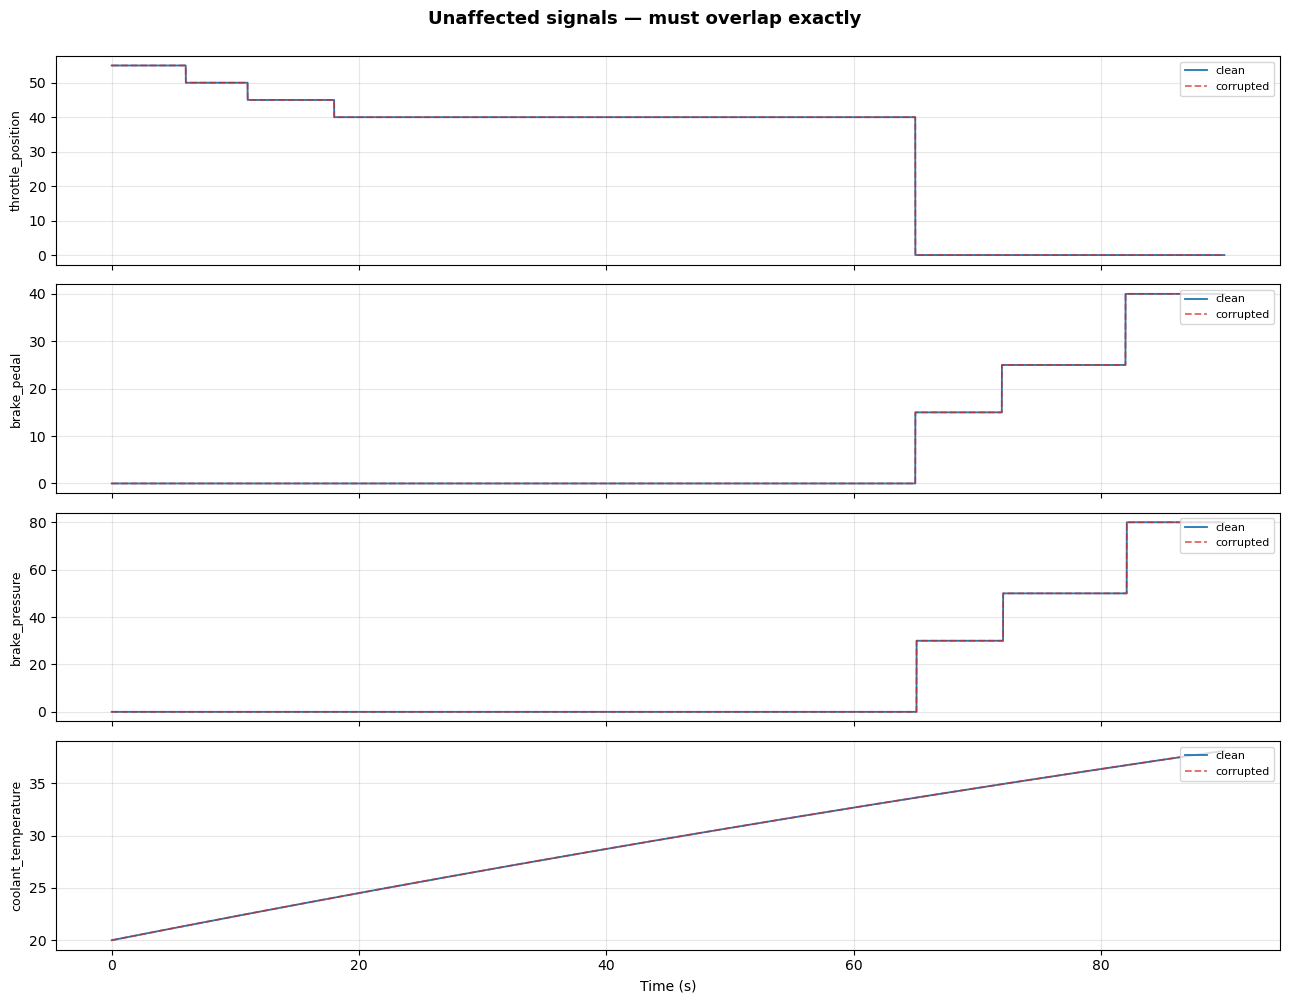

  throttle_position             byte-identical: True
  brake_pedal                   byte-identical: True
  brake_pressure                byte-identical: True
  coolant_temperature           byte-identical: True

✅ All unaffected signals are byte-identical.


In [6]:
# Unaffected signals must be byte-identical
unchanged_signals = [
    "throttle_position",
    "brake_pedal",
    "brake_pressure",
    "coolant_temperature",
]

fig, axes = plt.subplots(len(unchanged_signals), 1, figsize=(13, 2.5 * len(unchanged_signals)), sharex=True)

for ax, sig in zip(axes, unchanged_signals):
    ax.plot(clean_df["time_s"], clean_df[sig], label="clean", color="tab:blue", linewidth=1.3)
    ax.plot(corrupted_df["time_s"], corrupted_df[sig], label="corrupted",
            color="tab:red", linewidth=1.3, linestyle="--", alpha=0.7)
    ax.set_ylabel(sig, fontsize=9)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="upper right")

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Unaffected signals — must overlap exactly", fontsize=13, fontweight="bold", y=0.998)
plt.tight_layout()
plt.show()

# Byte-identical assertion
for sig in unchanged_signals:
    same = np.array_equal(clean_df[sig].values, corrupted_df[sig].values)
    print(f"  {sig:28s}  byte-identical: {same}")
    assert same, f"{sig} should be unchanged but isn't"

print("\n✅ All unaffected signals are byte-identical.")

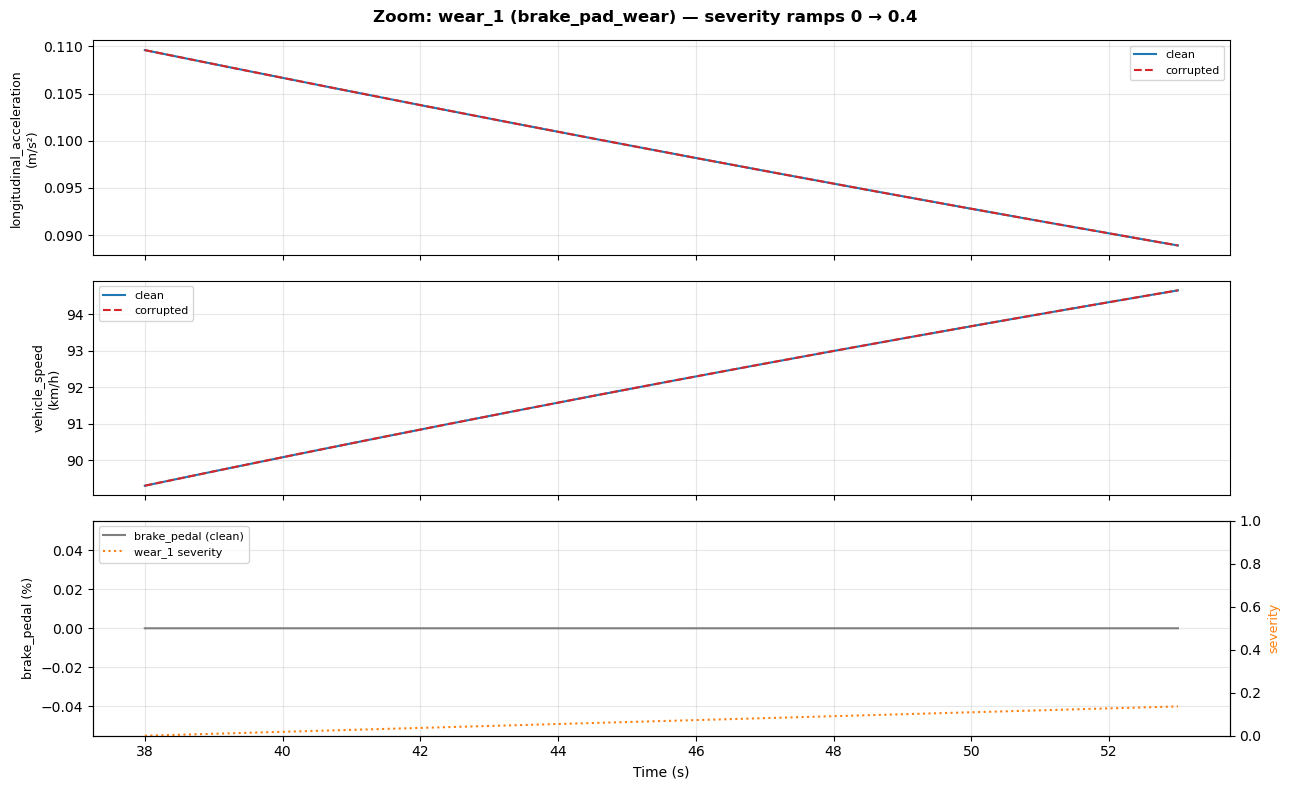

In [7]:
# Zoom in on the first fault window (wear_1)
import matplotlib.pyplot as plt

wear = next(f for f in scenario.resolved_faults if f.id == "wear_1")
pad = 5.0   # seconds of context around the window

# Show a window slightly inside the fault (not the full 44 s)
zoom_start = wear.onset_s
zoom_end = min(wear.onset_s + 15.0, wear.end_s)
mask = (clean_df["time_s"] >= zoom_start) & (clean_df["time_s"] <= zoom_end)

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

axes[0].plot(clean_df.loc[mask, "time_s"], clean_df.loc[mask, "longitudinal_acceleration"],
             label="clean", color="tab:blue", linewidth=1.5)
axes[0].plot(corrupted_df.loc[mask, "time_s"], corrupted_df.loc[mask, "longitudinal_acceleration"],
             label="corrupted", color="tab:red", linewidth=1.5, linestyle="--")
axes[0].set_ylabel("longitudinal_acceleration\n(m/s²)", fontsize=9)
axes[0].grid(alpha=0.3); axes[0].legend(fontsize=8)

axes[1].plot(clean_df.loc[mask, "time_s"], clean_df.loc[mask, "vehicle_speed"],
             label="clean", color="tab:blue", linewidth=1.5)
axes[1].plot(corrupted_df.loc[mask, "time_s"], corrupted_df.loc[mask, "vehicle_speed"],
             label="corrupted", color="tab:red", linewidth=1.5, linestyle="--")
axes[1].set_ylabel("vehicle_speed\n(km/h)", fontsize=9)
axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)

# Severity overlay on secondary y-axis
ax2 = axes[2].twinx()
axes[2].plot(clean_df.loc[mask, "time_s"], clean_df.loc[mask, "brake_pedal"],
             label="brake_pedal (clean)", color="tab:gray", linewidth=1.5)
from src.fault_injector import _compute_severity_array
t_zoom = clean_df.loc[mask, "time_s"].values
severity_zoom = _compute_severity_array(wear, t_zoom)
ax2.plot(t_zoom, severity_zoom, label="wear_1 severity", color="tab:orange", linewidth=1.5, linestyle=":")
ax2.set_ylabel("severity", fontsize=9, color="tab:orange")
ax2.set_ylim(0, 1.0)

axes[2].set_ylabel("brake_pedal (%)", fontsize=9)
axes[2].set_xlabel("Time (s)")
axes[2].grid(alpha=0.3)
lines1, labels1 = axes[2].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[2].legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper left")

fig.suptitle(f"Zoom: {wear.id} ({wear.type}) — severity ramps 0 → {wear.params['severity_end']}",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

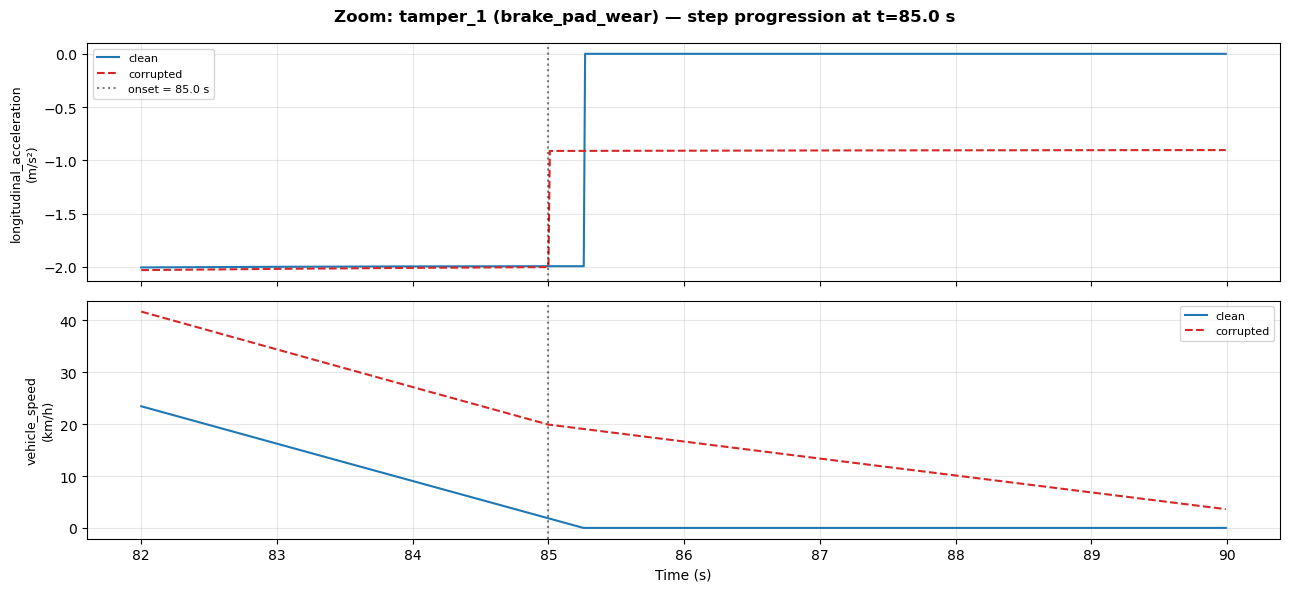

In [8]:
# Zoom in on the second fault (tamper_1, step progression)
tamper = next(f for f in scenario.resolved_faults if f.id == "tamper_1")

# Show 3 s before and after the step onset
zoom_start = tamper.onset_s - 3.0
zoom_end = min(tamper.end_s + 1.0, scenario.duration_s)
mask = (clean_df["time_s"] >= zoom_start) & (clean_df["time_s"] <= zoom_end)

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].plot(clean_df.loc[mask, "time_s"], clean_df.loc[mask, "longitudinal_acceleration"],
             label="clean", color="tab:blue", linewidth=1.5)
axes[0].plot(corrupted_df.loc[mask, "time_s"], corrupted_df.loc[mask, "longitudinal_acceleration"],
             label="corrupted", color="tab:red", linewidth=1.5, linestyle="--")
axes[0].axvline(tamper.onset_s, color="black", linestyle=":", alpha=0.5, label=f"onset = {tamper.onset_s:.1f} s")
axes[0].set_ylabel("longitudinal_acceleration\n(m/s²)", fontsize=9)
axes[0].grid(alpha=0.3); axes[0].legend(fontsize=8)

axes[1].plot(clean_df.loc[mask, "time_s"], clean_df.loc[mask, "vehicle_speed"],
             label="clean", color="tab:blue", linewidth=1.5)
axes[1].plot(corrupted_df.loc[mask, "time_s"], corrupted_df.loc[mask, "vehicle_speed"],
             label="corrupted", color="tab:red", linewidth=1.5, linestyle="--")
axes[1].axvline(tamper.onset_s, color="black", linestyle=":", alpha=0.5)
axes[1].set_ylabel("vehicle_speed\n(km/h)", fontsize=9)
axes[1].set_xlabel("Time (s)")
axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)

fig.suptitle(f"Zoom: {tamper.id} ({tamper.type}) — step progression at t={tamper.onset_s:.1f} s",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [9]:
# Summary of physical behavior
import numpy as np

# Pick a time inside wear_1's fault window, before tamper_1 starts
t_check = 70.0   # inside wear_1, well before tamper_1
row_clean = clean_df.loc[clean_df["time_s"] == t_check].iloc[0]
row_corrupt = corrupted_df.loc[corrupted_df["time_s"] == t_check].iloc[0]

print(f"Comparison at t = {t_check:.1f} s (inside wear_1 window)")
print(f"{'signal':30s}  {'clean':>12s}  {'corrupted':>12s}  {'delta':>10s}")
print("-" * 70)
for sig in clean_df.columns:
    if sig == "time_s":
        continue
    c = row_clean[sig]
    k = row_corrupt[sig]
    print(f"{sig:30s}  {c:12.4f}  {k:12.4f}  {k - c:+10.4f}")

# Verify the fault window has NONZERO effect on the cascade signals
fault_active = (scenario.resolved_faults[0].onset_s <= t_check <= scenario.resolved_faults[0].end_s)
assert fault_active, "Chosen time should be inside the wear_1 window"

# Verify cascade signals differ and others don't
for sig in ["longitudinal_acceleration", "vehicle_speed", "wheel_speed", "engine_rpm"]:
    assert not np.isclose(row_clean[sig], row_corrupt[sig]), f"{sig} should differ inside fault window"

for sig in ["throttle_position", "brake_pedal", "brake_pressure", "coolant_temperature"]:
    assert np.isclose(row_clean[sig], row_corrupt[sig], atol=1e-9), f"{sig} should be unchanged"

print()
print("✅ Verified at t=70.0 s:")
print("   - Cascade signals differ (fault is active)")
print("   - Unaffected signals are identical")

Comparison at t = 70.0 s (inside wear_1 window)
signal                                 clean     corrupted       delta
----------------------------------------------------------------------
throttle_position                     0.0000        0.0000     +0.0000
brake_pedal                          15.0000       15.0000     +0.0000
gear                                  4.0000        4.0000     +0.0000
longitudinal_acceleration            -0.9922       -0.8048     +0.1874
vehicle_speed                        79.6852       82.8801     +3.1949
engine_rpm                         2249.5521     2336.3128    +86.7607
coolant_temperature                  34.5677       34.5677     +0.0000
brake_pressure                       30.0000       30.0000     +0.0000
wheel_speed                          79.6852       82.8801     +3.1949

✅ Verified at t=70.0 s:
   - Cascade signals differ (fault is active)
   - Unaffected signals are identical
